<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/5.0%20Churn_Model_Selection%20and%20Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, inspect, text
from google.colab import userdata

engine = create_engine(userdata.get("NEON_DATABASE_URL"))

query = """
SELECT "CustomerID",
    "Recency",
    "Frequency",
    "TotalRevenue" AS "Monetary",
    "ObservedLifeSpan",
    "Tenure",
    "ProductDiversity",
    "CohortMonth",
    "Persona",
    "Churned"
FROM v_customer_metrics
INNER JOIN (SELECT "CustomerID",
            "Churned"
              FROM v_churn_analysis_candidates)
USING("CustomerID")
LEFT JOIN (SELECT "CustomerID",
          "Persona"
          FROM customer_segment_labels)
USING("CustomerID")
"""

df = pd.read_sql(text(query), con = engine)
print("Preview of sql query:")
df.head()

Preview of sql query:


,CustomerID,Recency,Frequency,Monetary,ObservedLifeSpan,Tenure,ProductDiversity,CohortMonth,Persona,Churned
0,12358.0,150,1,484.86,0,150,12,2011-07,One-Time Acquaintances,1
1,12364.0,112,1,623.92,0,112,34,2011-08,One-Time Acquaintances,0
2,12378.0,129,1,4008.62,0,129,219,2011-08,Loyal Steady Shoppers,1
3,12379.0,170,1,459.84,0,170,20,2011-06,One-Time Acquaintances,0
4,12380.0,185,1,607.55,0,185,36,2011-06,One-Time Acquaintances,0


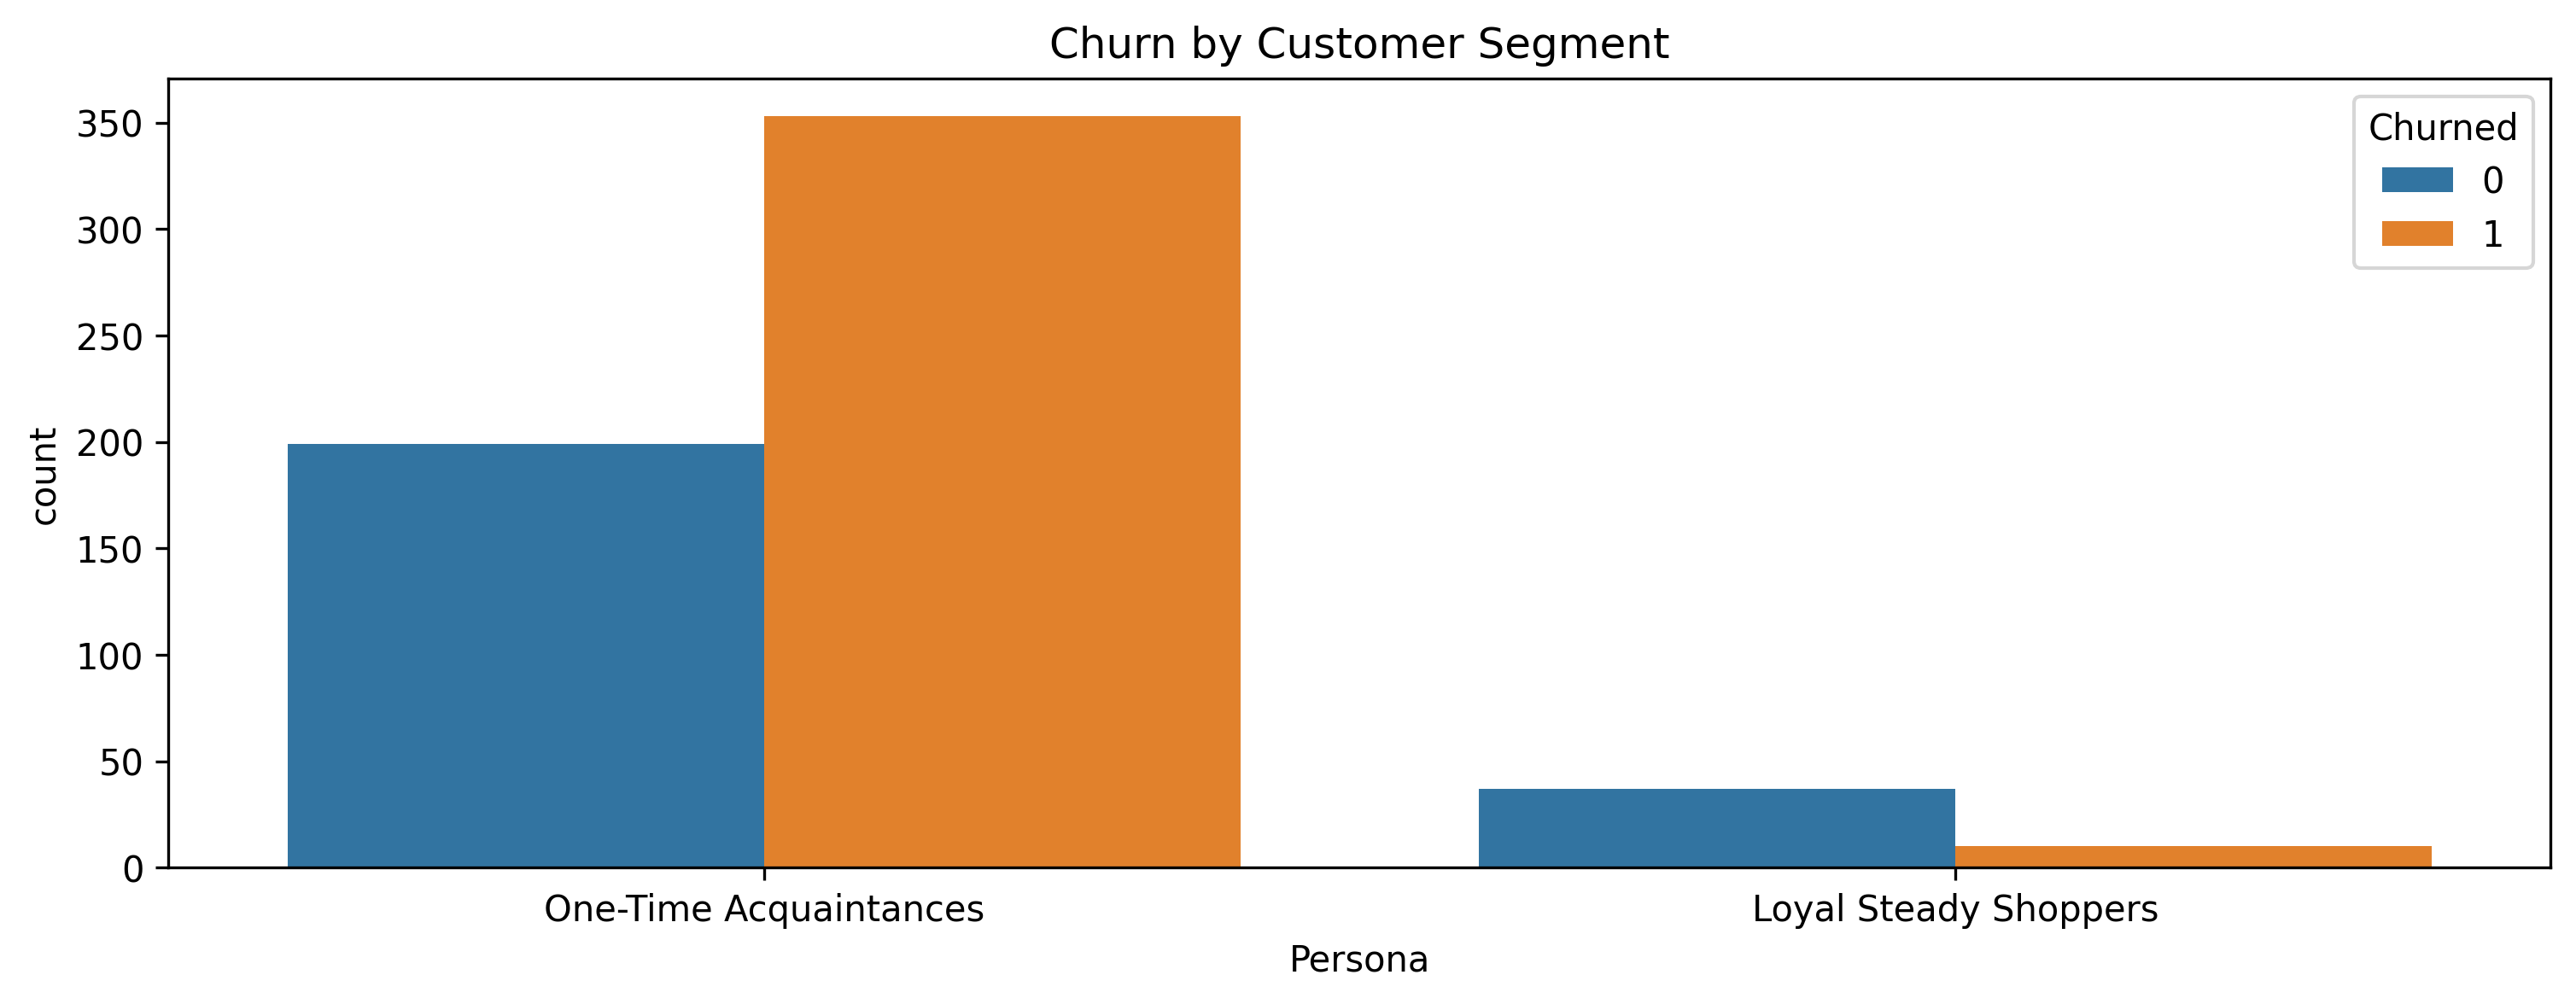

Persona,Loyal Steady Shoppers,One-Time Acquaintances
Churned,,
0,37,199
1,10,353


In [73]:
plt.figure(figsize = (12,4), dpi = 300)
sns.countplot(data = df, x = 'Persona', hue = 'Churned')
plt.title("Churn by Customer Segment")
plt.show()

df.groupby(['Persona', 'Churned']).size().unstack(level= 0)

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

X = df.drop('Churned', axis = 1)
X = pd.get_dummies(X, drop_first = True)
features = X.columns
X = X.values

y = df['Churned'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify = y)

scaler = StandardScaler()

models = [("Logistic Regression", LogisticRegression(max_iter = 1000, class_weight = 'balanced')),
          ("Random Forest", RandomForestClassifier(random_state = 42, class_weight = 'balanced')),
          ("Decision Tree", DecisionTreeClassifier(random_state = 42, class_weight = 'balanced')),
          ("Xgboost", XGBClassifier(random_state = 42)),
          ("Lightgbm", LGBMClassifier(random_state = 42, class_weight = 'balanced'))]

model_name = []
accuracy_avg = []
precision_avg = []
for name, model in models:
  kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
  accuracy_scores = cross_val_score(model, X_train, y_train, cv = kf, scoring = 'accuracy')
  precision_scores = cross_val_score(model, X_train, y_train, cv = kf, scoring = 'precision')

  model_name.append(name)
  accuracy_avg.append(accuracy_scores)
  precision_avg.append(precision_scores)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[LightGBM] [Info] Number of positive: 229, number of negative: 154
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000324 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 483
[LightGBM] [Info] Number of data points in the train set: 383, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/tmp/ipykernel_452/4239326217.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(accuracy_avg, labels = model_name)
/tmp/ipykernel_452/4239326217.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(precision_avg, labels = model_name)


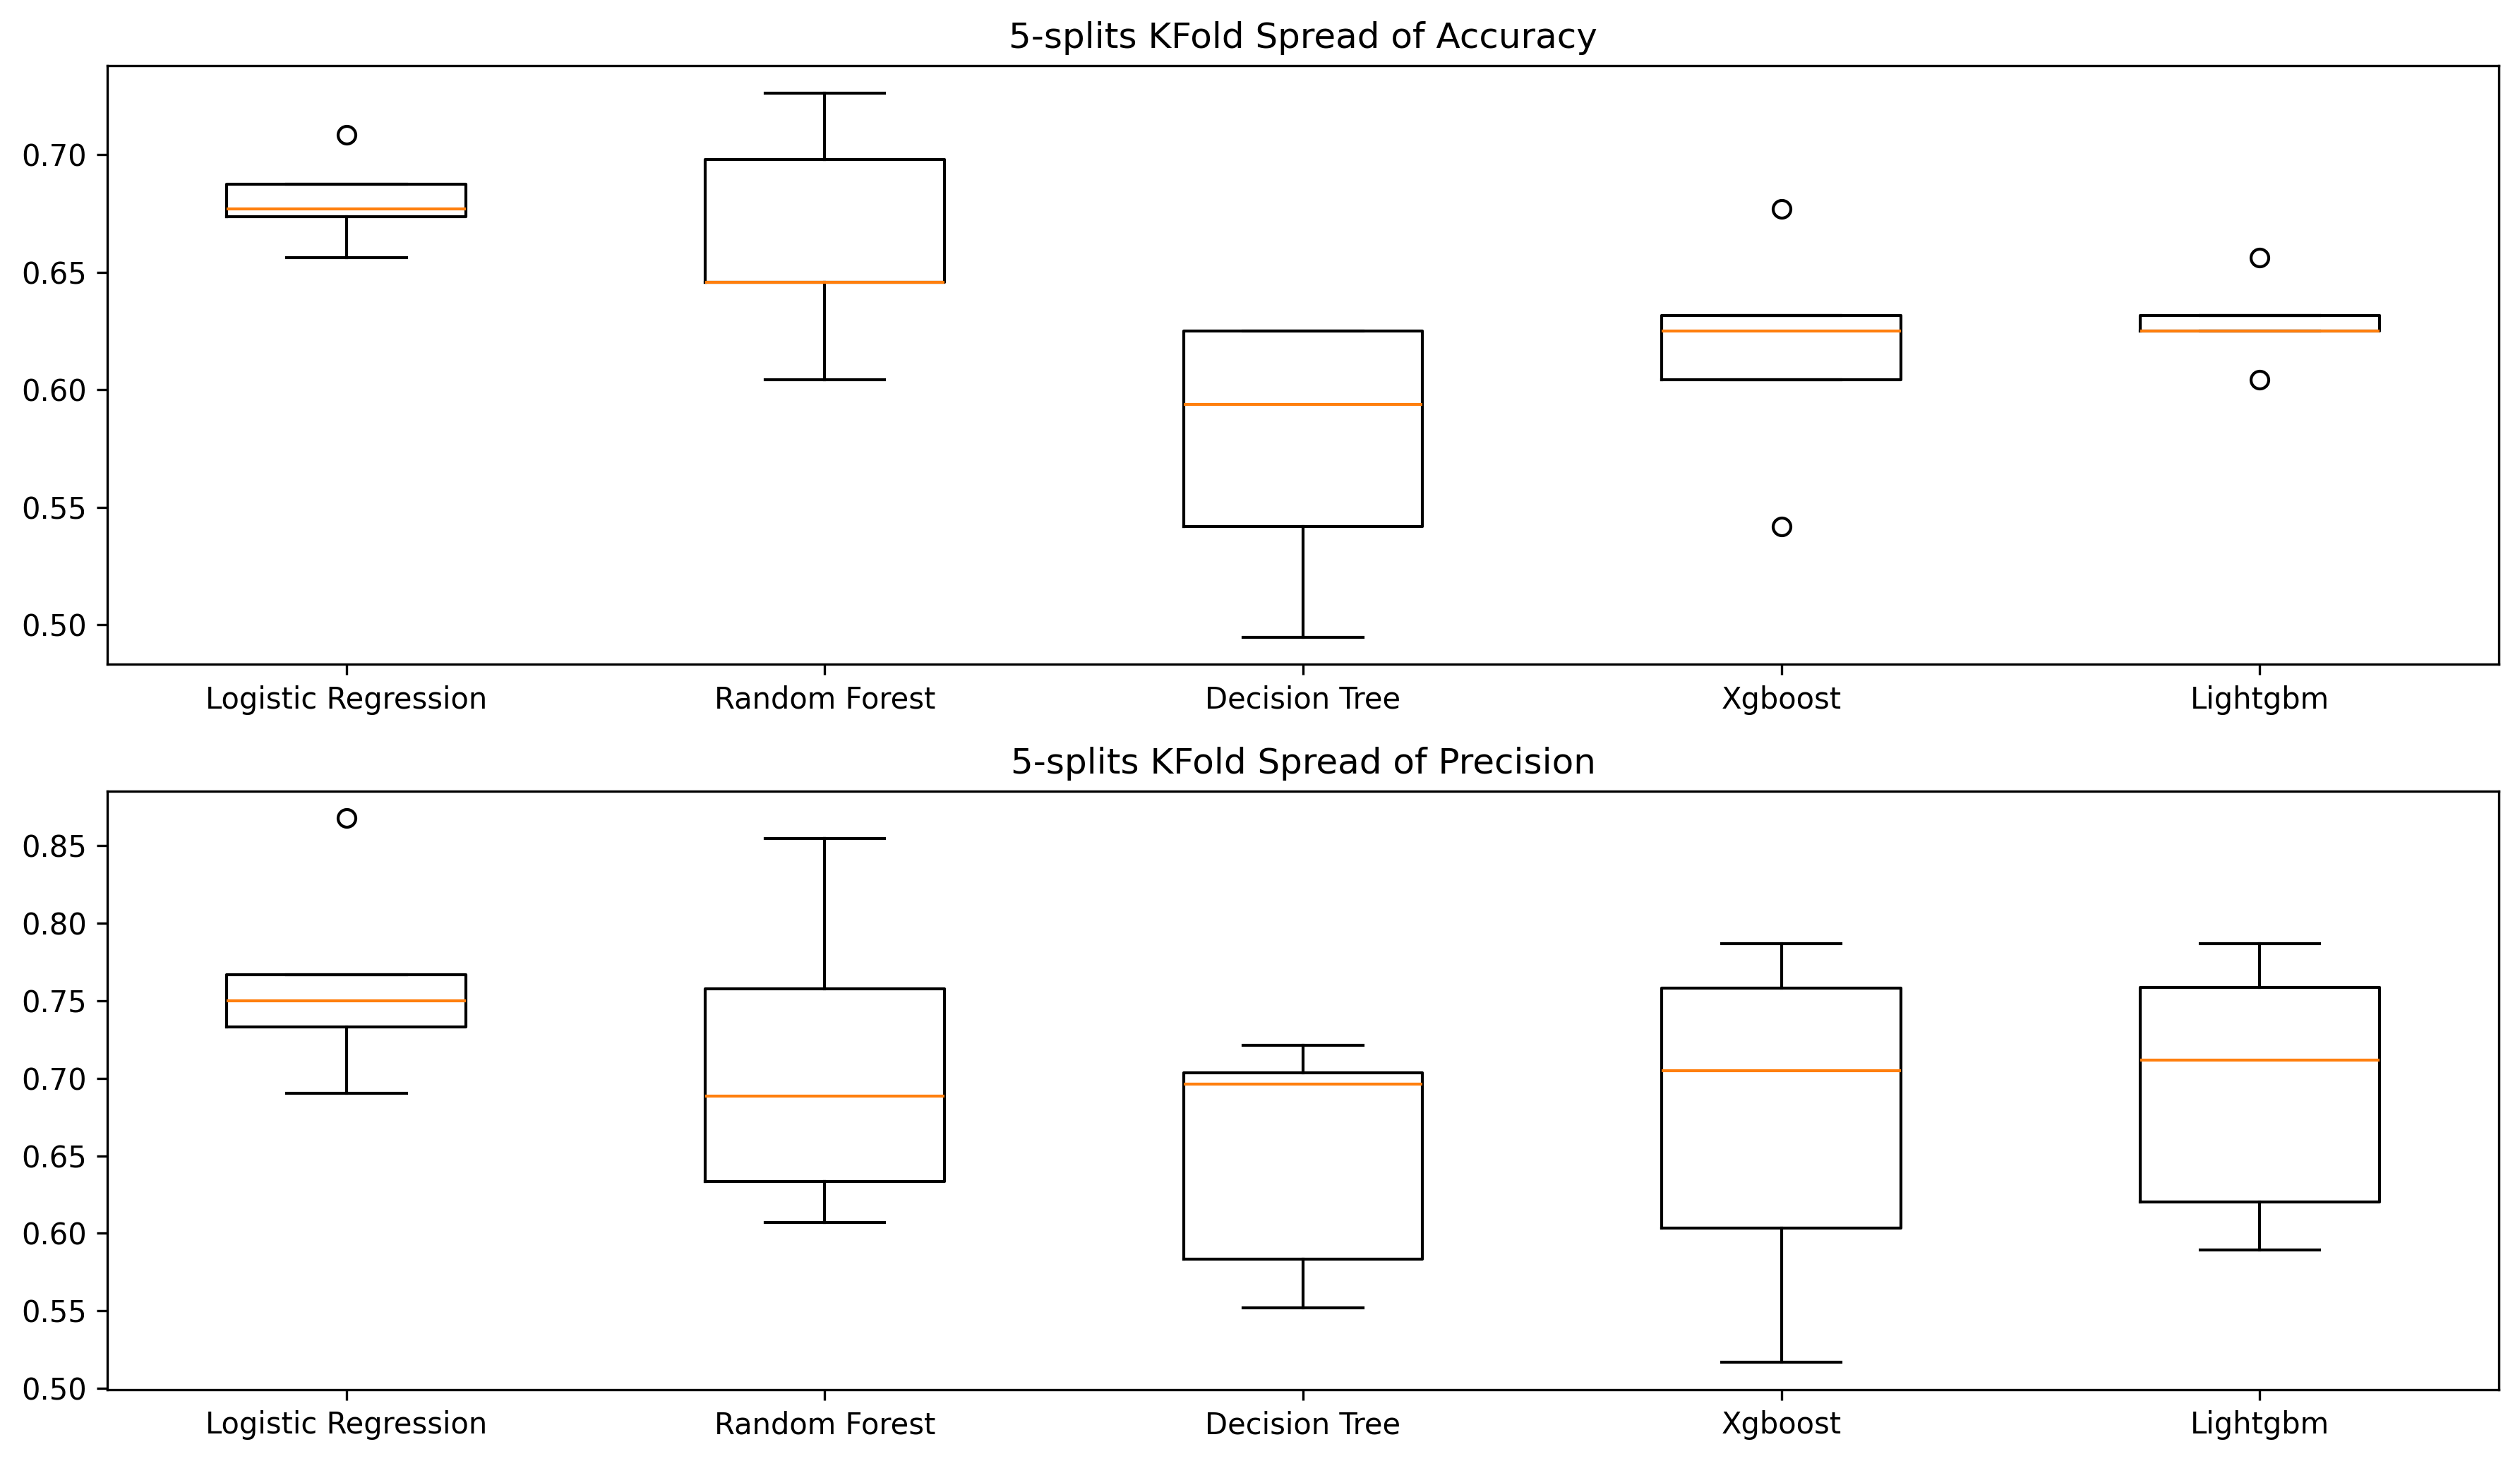

In [75]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize = (12,7), dpi = 300)
ax1.boxplot(accuracy_avg, labels = model_name)
ax1.set_title("5-splits KFold Spread of Accuracy")
ax2.boxplot(precision_avg, labels = model_name)
ax2.set_title("5-splits KFold Spread of Precision")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


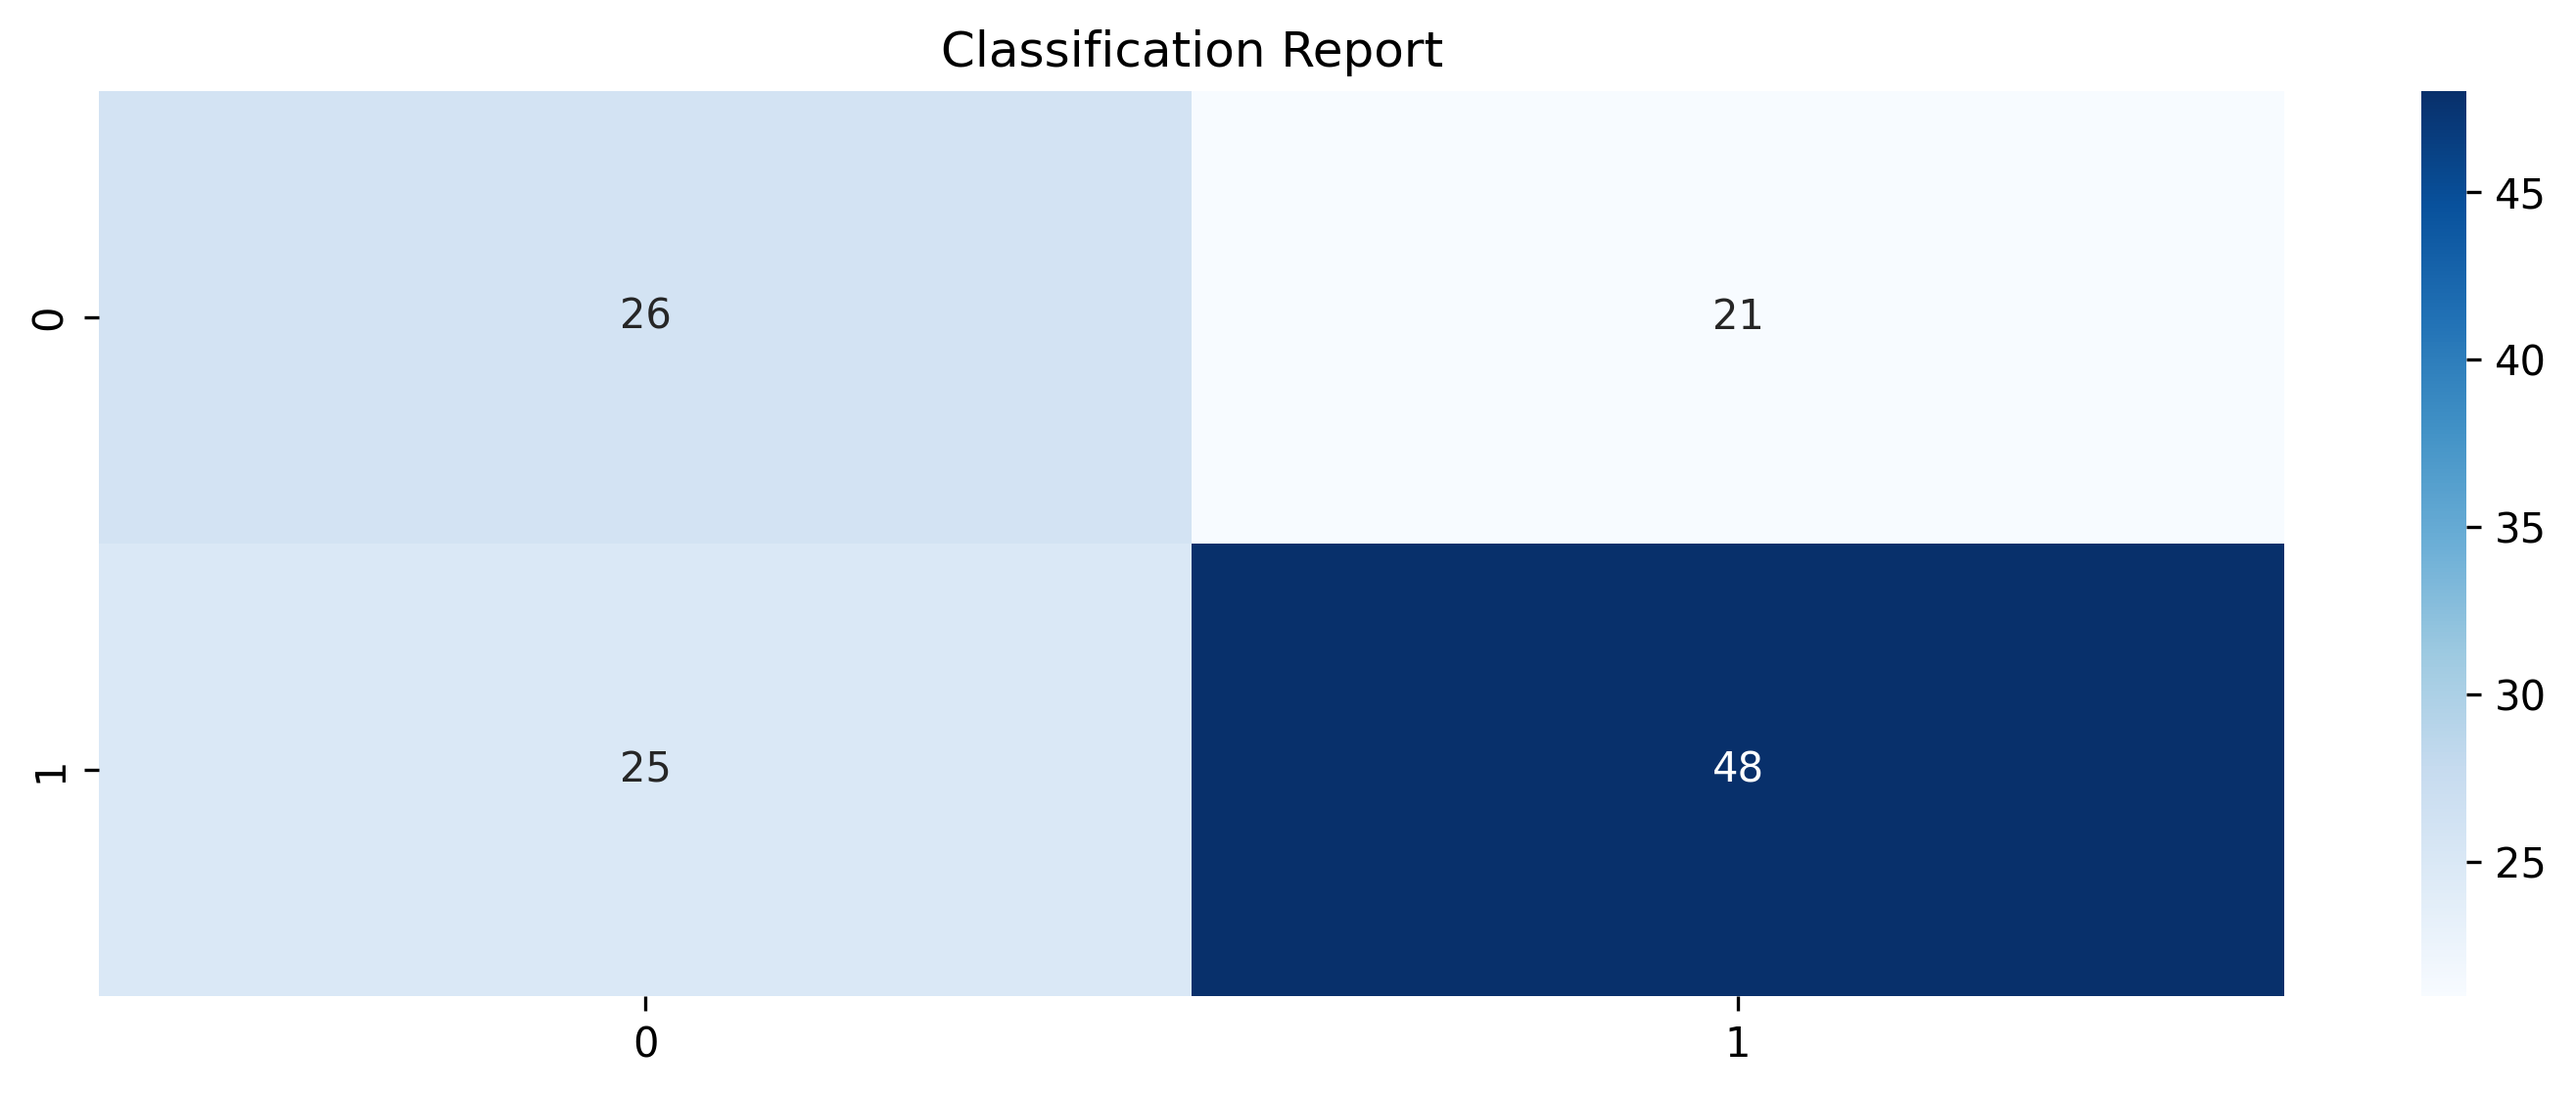

In [77]:
model = LogisticRegression(random_state = 42, class_weight = 'balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

c_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(c_matrix, cmap='Blues', annot = True, fmt = 'g')
plt.title("Classification Report")
plt.show()